## Method
look up vector for every word on the paragraph and calculate the mean. This might give me something like the vector of the whole paragraph
I'll use spacy's large model(these vectors are GloVe vectors)


In [2]:
import numpy as np
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

nlp = spacy.load("en_core_web_md")



In [ ]:
# --- 1. SETUP & DATA LOADING ---
print("Loading Spacy... (this handles the linguistic features)")
nlp = spacy.load("en_core_web_sm", disable=["ner"]) # Disable NER for speed

def load_and_label(path, label, target_style):
    """Reads a file and returns a DataFrame with proper labels."""
    try:
        with open(path, 'r', encoding='utf-8') as f:
            # Split by double newline to get paragraphs
            text = f.read()
            paragraphs = [p.strip() for p in text.split('\n\n') if len(p.split()) > 20]
        
        return pd.DataFrame({
            'text': paragraphs,
            'label': label,         # Human, AI_Generic, AI_Imposter
            'target_style': target_style # Lovecraft or Austen
        })
    except FileNotFoundError:
        print(f"Warning: File not found - {path}")
        return pd.DataFrame()

# file paths (Adjust if your folder structure is different)
files = [
    ("../data/processed/cthulhuchunked.txt", "Human", "Lovecraft"),
    ("../data/processed/prideprejudicechunked.txt", "Human", "Austen"),
    ("../data/generated/cthulhu_class2.txt", "AI_Generic", "Lovecraft"),
    ("../data/generated/prideprejudice_class2.txt", "AI_Generic", "Austen"),
    ("../data/generated/cthulhu_class3.txt", "AI_Imposter", "Lovecraft"),
    ("../data/generated/prideprejudice_class3.txt", "AI_Imposter", "Austen")
]

print("Reading text files...")
dfs = [load_and_label(*f) for f in files]
df = pd.concat(dfs, ignore_index=True)
print(f"Dataset loaded: {len(df)} paragraphs.")

Loading Spacy... (this handles the linguistic features)
Reading text files...
Dataset loaded: 2000 paragraphs.


In [14]:
def sentence_embedding(text):
    doc = nlp(text)
    return doc.vector

X_vectors = np.stack(df['text'].apply(sentence_embedding).values)
y_labels = df['label'].apply(lambda x: 0 if x == 'Human' else 1).values
print(f"Input Shape: {X_vectors.shape}")

Input Shape: (2000, 96)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

train_data = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).unsqueeze(1))
test_data = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test).unsqueeze(1))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [16]:
class SemanticNet(nn.Module):
    def __init__(self, input_dim=96):
        super(SemanticNet, self).__init__()

        # layer1
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        # layer2
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        # layer3
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.sigmoid(self.fc3(x))
        return x

model = SemanticNet(input_dim=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

print(model)

SemanticNet(
  (fc1): Linear(in_features=96, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch 5/20, Loss: 0.0000
Epoch 10/20, Loss: 0.0000
Epoch 15/20, Loss: 0.0000
Epoch 20/20, Loss: 0.0000


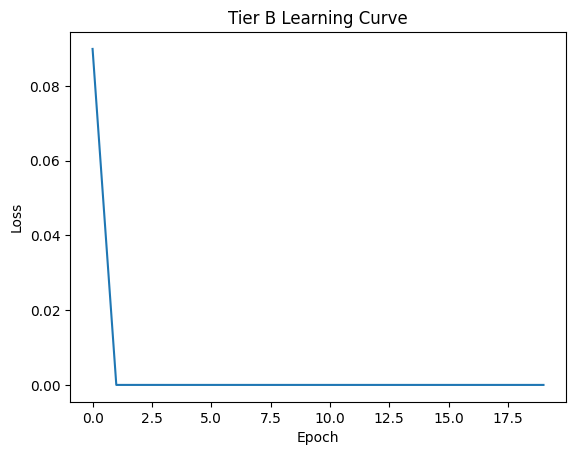

In [17]:
num_epochs = 20
train_losses = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

plt.plot(train_losses)
plt.title("Tier B Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [18]:
# Evaluate
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions.extend(y_pred.numpy())
        actuals.extend(y_batch.numpy())

# Flatten lists of arrays to 1D lists
actuals_flat = [int(a[0]) for a in actuals]
predictions_flat = [float(p[0]) for p in predictions]

# Convert probabilities to 0/1 predictions
y_pred_class = [1 if p > 0.5 else 0 for p in predictions_flat]

print("\n=== TIER B RESULTS (The Semanticist) ===")
print(classification_report(actuals_flat, y_pred_class, target_names=['Human', 'AI'], labels=[0, 1]))


=== TIER B RESULTS (The Semanticist) ===
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00         0
          AI       1.00      1.00      1.00       400

    accuracy                           1.00       400
   macro avg       0.50      0.50      0.50       400
weighted avg       1.00      1.00      1.00       400



/home/andaburger/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andaburger/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/andaburger/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

/tmp/ipykernel_22055/2708313922.py:8: UserWarning: Mismatched number of handles and labels: len(handles) = 1 len(labels) = 2
  plt.legend(handles=scatter.legend_elements()[0], labels=['Human', 'AI'])


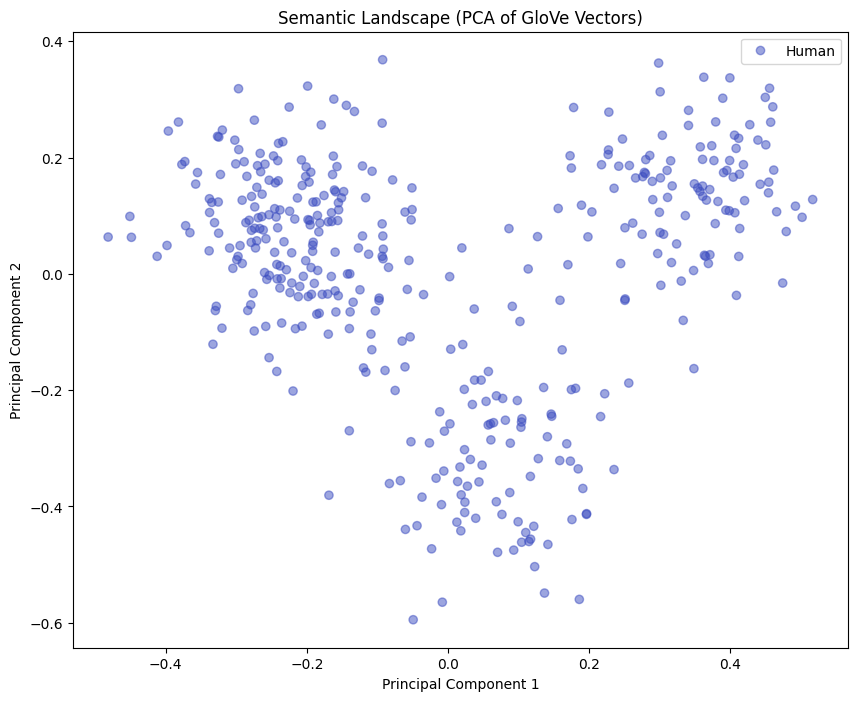

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_X = pca.fit_transform(X_test)

plt.figure(figsize=(10,8))
scatter = plt.scatter(reduced_X[:,0], reduced_X[:,1], c=y_test, cmap='coolwarm', alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0], labels=['Human', 'AI'])
plt.title("Semantic Landscape (PCA of GloVe Vectors)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()